# Comparison of proxy scatter and proxy residuals vs halo mass

This notebook makes:

1. a 1-row × 2-column scatter comparison for $Y_{\rm cyl}$ and $N_{\rm cyl}$;
2. a 1-row × 2-column normalized-residual comparison, $\langle\epsilon_S\rangle(M)$;
3. a 1-row × 2-column raw log-residual comparison, $\langle\delta\ln S\rangle(M)$.

For the residual plots, the parent black mean and gray 16--84% band use the same parent minimum-count threshold by default, so the gray band is drawn wherever the black parent mean is drawn.

In [1]:
# ---------------------------------------------------------------------
# Imports, paths, and global settings
# ---------------------------------------------------------------------

import numpy as np
import h5py
import pandas as pd
import matplotlib.pyplot as plt
from kllr import kllr_model

plt.rcParams["mathtext.fontset"] = "cm"
plt.rcParams["font.family"] = "serif"

YCYL_FILE = "data/wu22_eq8_Ycyl_selected_profiles_proj300_nscy_linear_with_mm_mPDF.h5"
RICH_FILE = "data/wu22_eq8_gdens1.0e-03_q180_proj300_chi6_mz20_with_mm_mPDF.h5"
DEFAULT_YCYL_RAW_FILE = "data/Compton_Y500c_in_cyl_projdepth300_m500c.1e13_hpz.hdf5"

_val = globals().get("YCYL_RAW_FILE", None)
if _val is None or (isinstance(_val, str) and _val.strip().lower() in ("", "none", "null")):
    YCYL_RAW_FILE = DEFAULT_YCYL_RAW_FILE
else:
    YCYL_RAW_FILE = Path(_val)

YCYL_SELECTOR = "Y500c_true"
MODEL_OBS = "Sigma"

SURVEY_LABELS = ["ACT-DR6", "ACT-DR6 Legacy", "SPT-SZ", "SPTpol 500d"]
YCYL_SELECTED_SURVEY_INDICES = [2, 3]

RICHNESS_BIN_LABELS = [
    r"$\lambda\in[60,\infty)$",
    r"$\lambda\in[45,60)$",
    r"$\lambda\in[30,45)$",
    r"$\lambda\in[20,30)$",
]
RICH_SELECTED_BIN_INDICES = [0, 1, 2, 3]


KLLR_KERNEL_WIDTH = 0.20
SELECTED_KLLR_BINS_MAX = 12
SELECTED_KLLR_MIN_POINTS = 40


print("YCYL_FILE:", YCYL_FILE)
print("RICH_FILE:", RICH_FILE)
print("YCYL_RAW_FILE:", YCYL_RAW_FILE)


YCYL_FILE: data/wu22_eq8_Ycyl_selected_profiles_proj300_nscy_linear_with_mm_mPDF.h5
RICH_FILE: data/wu22_eq8_gdens1.0e-03_q180_proj300_chi6_mz20_with_mm_mPDF.h5
YCYL_RAW_FILE: data/Compton_Y500c_in_cyl_projdepth300_m500c.1e13_hpz.hdf5


In [2]:
# ---------------------------------------------------------------------
# Generic helpers
# ---------------------------------------------------------------------

def collapse_kllr_curve(arr, xg, name="curve"):
    """Collapse possible KLLR extra dimensions to one 1D curve of length len(xg)."""
    arr = np.asarray(arr, dtype=float)
    xg = np.asarray(xg, dtype=float)
    G = len(xg)

    if arr.ndim == 1:
        if arr.size != G:
            raise ValueError(f"{name}: expected length {G}, got {arr.size}")
        return arr

    if arr.ndim == 2:
        if arr.shape[0] == G:
            return np.nanmean(arr, axis=1)
        if arr.shape[1] == G:
            return np.nanmean(arr, axis=0)

    for ax in range(arr.ndim):
        if arr.shape[ax] == G:
            other_axes = tuple(i for i in range(arr.ndim) if i != ax)
            return np.nanmean(arr, axis=other_axes)

    raise ValueError(f"{name}: cannot collapse shape {arr.shape} to length {G}")


def finite_positive_pair(mass, proxy):
    """Return finite positive mass/proxy pairs."""
    mass = np.asarray(mass, dtype=float)
    proxy = np.asarray(proxy, dtype=float)
    good = np.isfinite(mass) & (mass > 0) & np.isfinite(proxy) & (proxy > 0)
    return mass[good], proxy[good]


# ---------------------------------------------------------------------
# HDF5 loaders
# ---------------------------------------------------------------------

def model_path_for_proxy(source, selector, obs):
    if source == "ycyl":
        return f"selection_sets/{selector}/kllr_models/{obs}"
    if source == "richness":
        return f"kllr_models/{obs}"
    raise ValueError("source must be 'ycyl' or 'richness'")


def load_parent_proxy_model(fname, source, obs="Sigma", selector=None):
    """Load parent KLLR model for the selection proxy S: xg_X, mu_X, sig_X."""
    mpath = model_path_for_proxy(source, selector, obs)
    with h5py.File(fname, "r") as f:
        if mpath not in f:
            raise KeyError(f"Missing model path: {mpath}")
        g = f[mpath]
        xg = np.asarray(g["xg_X"][:], dtype=float)
        mu = collapse_kllr_curve(g["mu_X"][:], xg, name="mu_X")
        sig = collapse_kllr_curve(g["sig_X"][:], xg, name="sig_X")

    good = np.isfinite(xg) & np.isfinite(mu) & np.isfinite(sig) & (sig > 0)
    xg, mu, sig = xg[good], mu[good], sig[good]
    order = np.argsort(xg)
    return dict(logM=xg[order], M=np.exp(xg[order]), mu=mu[order], sig=sig[order])


def load_parent_proxy_scatter(fname, source, obs="Sigma", selector=None):
    model = load_parent_proxy_model(fname, source=source, obs=obs, selector=selector)
    return model["M"], model["sig"]


def get_survey_counts_from_ycyl_h5(fname, selector="Y500c_true"):
    fallback = np.array([458, 229, 138, 496], dtype=int)
    with h5py.File(fname, "r") as f:
        if "survey_counts" in f:
            return np.asarray(f["survey_counts"][:], dtype=int)
        meta_path = f"selection_sets/{selector}/meta"
        if meta_path in f and "n_sel" in f[meta_path]:
            return np.asarray(f[meta_path]["n_sel"][:], dtype=int)
    print("[warn] survey_counts not found; using fallback survey counts.")
    return fallback


def load_raw_ycyl_catalog(raw_file, selector="Y500c_true"):
    proxy_key_map = {"Y500c_true": "Y500c_cyl_ih", "Y5R500c_true": "Y5R500c_cyl_ih"}
    if selector not in proxy_key_map:
        raise ValueError(f"selector={selector!r} not supported by this helper")
    pkey = proxy_key_map[selector]

    with h5py.File(raw_file, "r") as f:
        if pkey not in f:
            raise KeyError(f"Missing {pkey} in {raw_file}")
        if "halo_mass(Msun/h)" in f:
            mass = np.asarray(f["halo_mass(Msun/h)"][:], dtype=float)
        elif "halo_mass" in f:
            mass = np.asarray(f["halo_mass"][:], dtype=float)
        else:
            raise KeyError(f"Could not find halo mass in {raw_file}")
        proxy = np.asarray(f[pkey][:], dtype=float)
        halo_id = np.asarray(f["halo_id"][:]) if "halo_id" in f else np.arange(len(proxy))
    return mass, proxy, halo_id, pkey


def select_topn_by_proxy(mass, proxy, halo_id, nsel):
    mass = np.asarray(mass, dtype=float)
    proxy = np.asarray(proxy, dtype=float)
    halo_id = np.asarray(halo_id)
    score = np.where(np.isfinite(proxy), proxy, -np.inf)
    order = np.argsort(score)[::-1]
    use = order[:int(nsel)]
    mass_sel = mass[use]
    proxy_sel = proxy[use]
    halo_id_sel = halo_id[use]
    good = np.isfinite(mass_sel) & (mass_sel > 0) & np.isfinite(proxy_sel) & (proxy_sel > 0)
    return mass_sel[good], proxy_sel[good], halo_id_sel[good]


def load_rich_selected_proxy_mass(rich_file, rich_idx, obs_group="Sigma"):
    result_path = f"results/{obs_group}"
    with h5py.File(rich_file, "r") as f:
        if result_path not in f:
            raise KeyError(f"Missing group: {result_path}")
        g = f[result_path]
        if "selected_masses" not in g or "selected_richness" not in g:
            raise KeyError(f"{result_path} lacks selected_masses / selected_richness")
        mass = np.asarray(g["selected_masses"][rich_idx], dtype=float)
        proxy = np.asarray(g["selected_richness"][rich_idx], dtype=float)
        if "n_sel" in g:
            n = int(np.asarray(g["n_sel"][:], dtype=int)[rich_idx])
            mass = mass[:n]
            proxy = proxy[:n]
    return finite_positive_pair(mass, proxy)


def load_ncyl_parent_proxy_mass(rich_file, obs_group="Sigma"):
    with h5py.File(rich_file, "r") as f:
        if "richness_ranked" in f and "mass_ranked_by_richness" in f:
            proxy = np.asarray(f["richness_ranked"][:], dtype=float)
            mass = np.asarray(f["mass_ranked_by_richness"][:], dtype=float)
            m, p = finite_positive_pair(mass, proxy)
            return m, p, "top-level ranked arrays"

        # Fallback: concatenate saved richness bins.
        result_path = f"results/{obs_group}"
        if result_path not in f:
            raise KeyError(f"Could not find ranked arrays or fallback group {result_path}")
        g = f[result_path]
        if "selected_masses" not in g or "selected_richness" not in g:
            raise KeyError(f"{result_path} lacks selected_masses / selected_richness")
        mass_pieces, proxy_pieces = [], []
        for i in range(g["selected_masses"].shape[0]):
            m = np.asarray(g["selected_masses"][i], dtype=float)
            p = np.asarray(g["selected_richness"][i], dtype=float)
            m, p = finite_positive_pair(m, p)
            mass_pieces.append(m)
            proxy_pieces.append(p)
    mass = np.concatenate(mass_pieces)
    proxy = np.concatenate(proxy_pieces)
    return mass, proxy, "fallback concatenated selected bins"

In [3]:
# ---------------------------------------------------------------------
# Build parent and selected proxy samples
# ---------------------------------------------------------------------

def build_ycyl_samples():
    mass_all, proxy_all, halo_id_all, ykey = load_raw_ycyl_catalog(YCYL_RAW_FILE, selector=YCYL_SELECTOR)
    counts = get_survey_counts_from_ycyl_h5(YCYL_FILE, selector=YCYL_SELECTOR)
    selected = {}
    for survey_idx in YCYL_SELECTED_SURVEY_INDICES:
        survey_name = SURVEY_LABELS[survey_idx]
        nsel = int(counts[survey_idx])
        msel, psel, hsel = select_topn_by_proxy(mass_all, proxy_all, halo_id_all, nsel)
        selected[survey_name] = dict(mass=msel, proxy=psel, halo_id=hsel,
                                     nsel_requested=nsel, nsel_used=len(msel))
    parent = dict(mass=mass_all, proxy=proxy_all, halo_id=halo_id_all, proxy_key=ykey)
    return parent, selected


def build_ncyl_samples():
    mass_all, proxy_all, msg = load_ncyl_parent_proxy_mass(RICH_FILE, obs_group=MODEL_OBS)
    selected = {}
    for rich_idx in RICH_SELECTED_BIN_INDICES:
        label = RICHNESS_BIN_LABELS[rich_idx]
        msel, psel = load_rich_selected_proxy_mass(RICH_FILE, rich_idx, obs_group=MODEL_OBS)
        selected[label] = dict(mass=msel, proxy=psel, nsel_used=len(msel), rich_idx=rich_idx)
    parent = dict(mass=mass_all, proxy=proxy_all, source_message=msg)
    return parent, selected


ycyl_parent_sample, ycyl_selected_samples = build_ycyl_samples()
ncyl_parent_sample, ncyl_selected_samples = build_ncyl_samples()

print("Ycyl parent N:", len(ycyl_parent_sample["mass"]), "proxy key:", ycyl_parent_sample["proxy_key"])
for name, d in ycyl_selected_samples.items():
    print(f"  {name}: N requested={d['nsel_requested']}, N used={d['nsel_used']}")
print("Ncyl parent N:", len(ncyl_parent_sample["mass"]), ncyl_parent_sample["source_message"])
for name, d in ncyl_selected_samples.items():
    print(f"  {name}: N used={d['nsel_used']}")

Ycyl parent N: 83731 proxy key: Y500c_cyl_ih
  SPT-SZ: N requested=138, N used=138
  SPTpol 500d: N requested=496, N used=496
Ncyl parent N: 74605 top-level ranked arrays
  $\lambda\in[60,\infty)$: N used=257
  $\lambda\in[45,60)$: N used=370
  $\lambda\in[30,45)$: N used=1103
  $\lambda\in[20,30)$: N used=2396


In [4]:
# ---------------------------------------------------------------------
# Residual computation relative to the parent KLLR model
# ---------------------------------------------------------------------

def compute_proxy_residuals(mass, proxy, model, min_sig=1e-8):
    mass, proxy = finite_positive_pair(mass, proxy)
    lnM = np.log(mass)
    lnS = np.log(proxy)
    in_range = (
        np.isfinite(lnM)
        & (lnM >= np.nanmin(model["logM"]))
        & (lnM <= np.nanmax(model["logM"]))
    )
    mass, proxy, lnM, lnS = mass[in_range], proxy[in_range], lnM[in_range], lnS[in_range]
    mu = np.interp(lnM, model["logM"], model["mu"])
    sig = np.interp(lnM, model["logM"], model["sig"])
    good = np.isfinite(mu) & np.isfinite(sig) & (sig > min_sig)
    mass, proxy, lnM, lnS, mu, sig = mass[good], proxy[good], lnM[good], lnS[good], mu[good], sig[good]
    delta = lnS - mu
    eps = delta / sig
    return dict(mass=mass, proxy=proxy, lnM=lnM, lnS=lnS, mu=mu, sig=sig, delta=delta, eps=eps)


ycyl_parent_model = load_parent_proxy_model(YCYL_FILE, source="ycyl", obs=MODEL_OBS, selector=YCYL_SELECTOR)
ncyl_parent_model = load_parent_proxy_model(RICH_FILE, source="richness", obs=MODEL_OBS, selector=None)

ycyl_parent_res = compute_proxy_residuals(ycyl_parent_sample["mass"], ycyl_parent_sample["proxy"], ycyl_parent_model)
ncyl_parent_res = compute_proxy_residuals(ncyl_parent_sample["mass"], ncyl_parent_sample["proxy"], ncyl_parent_model)

ycyl_selected_residuals = {}
for name, d in ycyl_selected_samples.items():
    res = compute_proxy_residuals(d["mass"], d["proxy"], ycyl_parent_model)
    res["nsel_used"] = len(res["mass"])
    ycyl_selected_residuals[name] = res

ncyl_selected_residuals = {}
for name, d in ncyl_selected_samples.items():
    res = compute_proxy_residuals(d["mass"], d["proxy"], ncyl_parent_model)
    res["nsel_used"] = len(res["mass"])
    ncyl_selected_residuals[name] = res

print("Ycyl parent residual N:", len(ycyl_parent_res["mass"]))
for name, res in ycyl_selected_residuals.items():
    print(f"  {name}: residual N={res['nsel_used']}, mean eps={np.nanmean(res['eps']):.3f}, mean delta={np.nanmean(res['delta']):.3f}")
print("Ncyl parent residual N:", len(ncyl_parent_res["mass"]))
for name, res in ncyl_selected_residuals.items():
    print(f"  {name}: residual N={res['nsel_used']}, mean eps={np.nanmean(res['eps']):.3f}, mean delta={np.nanmean(res['delta']):.3f}")

Ycyl parent residual N: 83731
  SPT-SZ: residual N=138, mean eps=0.203, mean delta=0.020
  SPTpol 500d: residual N=496, mean eps=0.416, mean delta=0.099
Ncyl parent residual N: 74605
  $\lambda\in[60,\infty)$: residual N=257, mean eps=1.709, mean delta=0.998
  $\lambda\in[45,60)$: residual N=370, mean eps=1.649, mean delta=0.938
  $\lambda\in[30,45)$: residual N=1103, mean eps=1.789, mean delta=0.940
  $\lambda\in[20,30)$: residual N=2396, mean eps=1.646, mean delta=0.824


In [5]:
# ---------------------------------------------------------------------
# Residual-vs-mass binning and plotting helpers
# ---------------------------------------------------------------------

def make_log_mass_edges_from_residuals(parent_res, n_bins=14):
    lnM = np.asarray(parent_res["lnM"], dtype=float)
    good = np.isfinite(lnM)
    if np.sum(good) < 2:
        raise ValueError("Not enough finite parent lnM values to make mass bins")
    lo = float(np.nanmin(lnM[good]))
    hi = float(np.nanmax(lnM[good]))
    edges = np.linspace(lo, hi, int(n_bins) + 1)
    edges[0] -= 1e-10
    edges[-1] += 1e-10
    return edges


def binned_residual_curve(res, value_key="eps", edges_lnM=None, min_count=5):
    if edges_lnM is None:
        raise ValueError("edges_lnM must be provided")
    lnM = np.asarray(res["lnM"], dtype=float)
    y = np.asarray(res[value_key], dtype=float)
    edges_lnM = np.asarray(edges_lnM, dtype=float)
    nbin = len(edges_lnM) - 1
    M_mid = np.exp(0.5 * (edges_lnM[:-1] + edges_lnM[1:]))
    mean = np.full(nbin, np.nan)
    median = np.full(nbin, np.nan)
    p16 = np.full(nbin, np.nan)
    p84 = np.full(nbin, np.nan)
    std = np.full(nbin, np.nan)
    sem = np.full(nbin, np.nan)
    count = np.zeros(nbin, dtype=int)
    b = np.digitize(lnM, edges_lnM, right=False) - 1
    b = np.where(lnM >= edges_lnM[-1], nbin - 1, b)
    for i in range(nbin):
        sel = (b == i) & np.isfinite(y)
        n = int(np.sum(sel))
        count[i] = n
        if n < min_count:
            continue
        yy = y[sel]
        mean[i] = np.nanmean(yy)
        median[i] = np.nanmedian(yy)
        p16[i] = np.nanpercentile(yy, 16)
        p84[i] = np.nanpercentile(yy, 84)
        std[i] = np.nanstd(yy, ddof=1) if n > 1 else 0.0
        sem[i] = std[i] / np.sqrt(n) if n > 0 else np.nan
    return dict(M_mid=M_mid, mean=mean, median=median, p16=p16, p84=p84, std=std, sem=sem, count=count)


def print_parent_count_diagnostics(parent_res, edges_lnM, label, min_mean=5, min_band=5):
    curve = binned_residual_curve(parent_res, value_key="eps", edges_lnM=edges_lnM, min_count=1)
    print("=" * 90)
    print(label)
    print("=" * 90)
    print(f"{'bin':>3s} {'M_mid [Msun/h]':>16s} {'N_parent':>10s} {'mean?':>8s} {'band?':>8s}")
    for i, (M, n) in enumerate(zip(curve["M_mid"], curve["count"])):
        print(f"{i:3d} {M:16.4e} {n:10d} {str(n >= min_mean):>8s} {str(n >= min_band):>8s}")




def plot_residual_mass_panel(
    ax,
    parent_res,
    selected_residuals,
    *,
    edges_lnM,
    value_key="eps",
    proxy_label=r"$Y_{\rm cyl}$",
    ylabel=None,
    selected_colors=None,
    min_count_parent_mean=5,
    min_count_parent_band=5,
    min_count_selected=5,
    show_parent_band=True,
    show_selected_sem=True,
    # --- new options for individual points ---
    show_individual_points=True,
    parent_point_alpha=0.30,
    selected_point_alpha=0.30,
    parent_point_size=8,
    selected_point_size=14,
    parent_point_color="0.65",
    rasterized_points=True,
):
    """
    One panel: parent and selected residuals vs halo mass.

    Adds optional individual-halo residual points:
      - parent halos as gray points
      - selected halos as colored points
    """

    if selected_colors is None:
        selected_colors = {}

    # ------------------------------------------------------------
    # 0) Individual halo points
    # ------------------------------------------------------------
    if show_individual_points:
        # Parent sample points
        x_parent = np.asarray(parent_res["mass"], dtype=float)
        y_parent = np.asarray(parent_res[value_key], dtype=float)

        good_parent_pts = (
            np.isfinite(x_parent) & (x_parent > 0.0) &
            np.isfinite(y_parent)
        )

        ax.scatter(
            x_parent[good_parent_pts],
            y_parent[good_parent_pts],
            s=parent_point_size,
            alpha=parent_point_alpha,
            color=parent_point_color,
            edgecolors="none",
            zorder=0,
            rasterized=rasterized_points,
            label=None,
        )

        # Selected sample points
        for i, (name, res) in enumerate(selected_residuals.items()):
            color = selected_colors.get(name, f"C{i}")

            x_sel = np.asarray(res["mass"], dtype=float)
            y_sel = np.asarray(res[value_key], dtype=float)

            good_sel_pts = (
                np.isfinite(x_sel) & (x_sel > 0.0) &
                np.isfinite(y_sel)
            )

            ax.scatter(
                x_sel[good_sel_pts],
                y_sel[good_sel_pts],
                s=selected_point_size,
                alpha=selected_point_alpha,
                color=color,
                edgecolors="none",
                zorder=1,
                rasterized=rasterized_points,
                label=None,
            )

    # ------------------------------------------------------------
    # 1) Parent binned curves
    # ------------------------------------------------------------
    pcurve_mean = binned_residual_curve(
        parent_res,
        value_key=value_key,
        edges_lnM=edges_lnM,
        min_count=min_count_parent_mean,
    )

    pcurve_band = binned_residual_curve(
        parent_res,
        value_key=value_key,
        edges_lnM=edges_lnM,
        min_count=min_count_parent_band,
    )

    M = pcurve_mean["M_mid"]

    if show_parent_band:
        good_band = np.isfinite(pcurve_band["p16"]) & np.isfinite(pcurve_band["p84"])
        ax.fill_between(
            M[good_band],
            pcurve_band["p16"][good_band],
            pcurve_band["p84"][good_band],
            color="#FFDE42", #"0.75",
            alpha=0.25,
            label=fr"parent 16-84%, $N_{{\rm bin}}\geq {min_count_parent_band}$",
            zorder=2,
        )

    good_parent = np.isfinite(pcurve_mean["mean"])
    ax.plot(
        M[good_parent],
        pcurve_mean["mean"][good_parent],
        color="k",
        linewidth=2.6,
        label=fr"parent mean, $N_{{\rm bin}}\geq {min_count_parent_mean}$",
        zorder=5,
    )

    # ------------------------------------------------------------
    # 2) Selected binned curves
    # ------------------------------------------------------------
    for i, (name, res) in enumerate(selected_residuals.items()):
        color = selected_colors.get(name, f"C{i}")

        scurve = binned_residual_curve(
            res,
            value_key=value_key,
            edges_lnM=edges_lnM,
            min_count=min_count_selected,
        )

        good = np.isfinite(scurve["mean"])
        if not np.any(good):
            print(f"[skip] no valid mass bins for {name}, value_key={value_key}")
            continue

        label = fr"{name}: $N={res.get('nsel_used', len(res['mass']))}$"
        ls_sels = [(10,5), (3,3)]
        if show_selected_sem:
            ax.errorbar(
                scurve["M_mid"][good],
                scurve["mean"][good],
                yerr=scurve["sem"][good],
                marker="o",
                markersize=2,
                ls='--',
                dashes=(5,5),
                linewidth=2.2,
                capsize=5,
                color=color,
                label=label,
                zorder=6,
            )
        else:
            ax.plot(
                scurve["M_mid"][good],
                scurve["mean"][good],
                marker="o",
                markersize=2,
                ls='--',
                dashes=(5,5),
                linewidth=2.2,
                color=color,
                label=label,
                zorder=6,
            )

    # ------------------------------------------------------------
    # 3) Cosmetics
    # ------------------------------------------------------------
    ax.axhline(0.0, color="0.3", linestyle=":", linewidth=1.2, zorder=0)
    ax.set_xscale("log")
    ax.set_xlabel(r"$M_{500c}\,[h^{-1}M_\odot]$", fontsize=23)

    if ylabel is not None:
        ax.set_ylabel(ylabel, fontsize=23)

    ax.set_title(proxy_label, fontsize=26)
    ax.grid(True, which="both", alpha=0.25)
    ax.tick_params(
        axis="both",
        which="both",
        labelsize=20,
        top=True,
        right=True,
        direction="in",
    )
    ax.minorticks_on()


def plot_proxy_residuals_vs_mass_two_cols(
    *,
    ycyl_parent_res,
    ycyl_selected_residuals,
    ncyl_parent_res,
    ncyl_selected_residuals,
    value_key="eps",
    n_mass_bins=14, 
    min_count_parent_mean=5,
    min_count_parent_band=5,
    min_count_selected=5,
    savepath=None,
    # --- new options ---
    show_individual_points=True,
    parent_point_alpha=0.30,
    selected_point_alpha=0.30,
    parent_point_size=8,
    selected_point_size=14,
):
    """
    Two-column figure:
      left  = Ycyl residual vs mass
      right = Ncyl residual vs mass
    """
    if value_key == "eps":
        ylabel = r"Normalized residual $\langle\epsilon_{s_2}\rangle$"
    elif value_key == "delta":
        ylabel = r"Residual $\langle\delta s_2\rangle$"
    else:
        ylabel = value_key

    edges_y = make_log_mass_edges_from_model(ycyl_parent_model, n_bins=n_mass_bins)
    edges_n = make_log_mass_edges_from_model(ncyl_parent_model, n_bins=n_mass_bins)

    fig, axes = plt.subplots(1, 2, figsize=(12, 6.5), sharex=True, sharey=True)
    ax_y, ax_n = axes

    ycyl_colors = {
        "SPT-SZ": "C0",
        "SPTpol 500d": "C1",
    }

    rich_colors = {
        RICHNESS_BIN_LABELS[0]: "C0",
        RICHNESS_BIN_LABELS[1]: "C1",
        RICHNESS_BIN_LABELS[2]: "C2",
        RICHNESS_BIN_LABELS[3]: "#D62828", #"C3",
    }

    plot_residual_mass_panel(
        ax_y,
        ycyl_parent_res,
        ycyl_selected_residuals,
        edges_lnM=edges_y,
        value_key=value_key,
        proxy_label=r"$\ln Y_{\rm cyl}$",
        ylabel=ylabel,
        selected_colors=ycyl_colors,
        min_count_parent_mean=min_count_parent_mean,
        min_count_parent_band=min_count_parent_band,
        min_count_selected=min_count_selected,
        show_individual_points=show_individual_points,
        parent_point_alpha=parent_point_alpha,
        selected_point_alpha=selected_point_alpha,
        parent_point_size=parent_point_size,
        selected_point_size=selected_point_size,
    )

    plot_residual_mass_panel(
        ax_n,
        ncyl_parent_res,
        ncyl_selected_residuals,
        edges_lnM=edges_n,
        value_key=value_key,
        proxy_label=r"$\ln N_{\rm cyl}$",
        ylabel=None,#ylabel,
        selected_colors=rich_colors,
        min_count_parent_mean=min_count_parent_mean,
        min_count_parent_band=min_count_parent_band,
        min_count_selected=min_count_selected,
        show_individual_points=show_individual_points,
        parent_point_alpha=parent_point_alpha,
        selected_point_alpha=selected_point_alpha,
        parent_point_size=parent_point_size,
        selected_point_size=selected_point_size,
    )

    ax_y.legend(frameon=False, fontsize=16, loc="best",
                columnspacing=0.5, handletextpad=0.8, handlelength=2.2,
               )
    ax_n.legend(frameon=False, fontsize=14.2, loc="best", #loc=[0.01,0.05],#
                columnspacing=0.5, handletextpad=0.8, handlelength=2.2,
                ncols=1)

    fig.tight_layout()
    fig.subplots_adjust(wspace=0.0, hspace=0.0)

    if savepath is not None:
        savepath = Path(savepath)
        fig.savefig(savepath, dpi=180, bbox_inches="tight")
        fig.savefig(savepath.with_suffix(".pdf"), bbox_inches="tight")
        print("Saved:", savepath)
        print("Saved:", savepath.with_suffix(".pdf"))

    return fig, axes


def make_log_mass_edges_from_model(model, n_bins=16):
    """
    Use the parent KLLR model mass range to define common mass bins.
    """
    lo = float(np.nanmin(model["logM"]))
    hi = float(np.nanmax(model["logM"]))
    return np.linspace(lo, hi, int(n_bins) + 1)



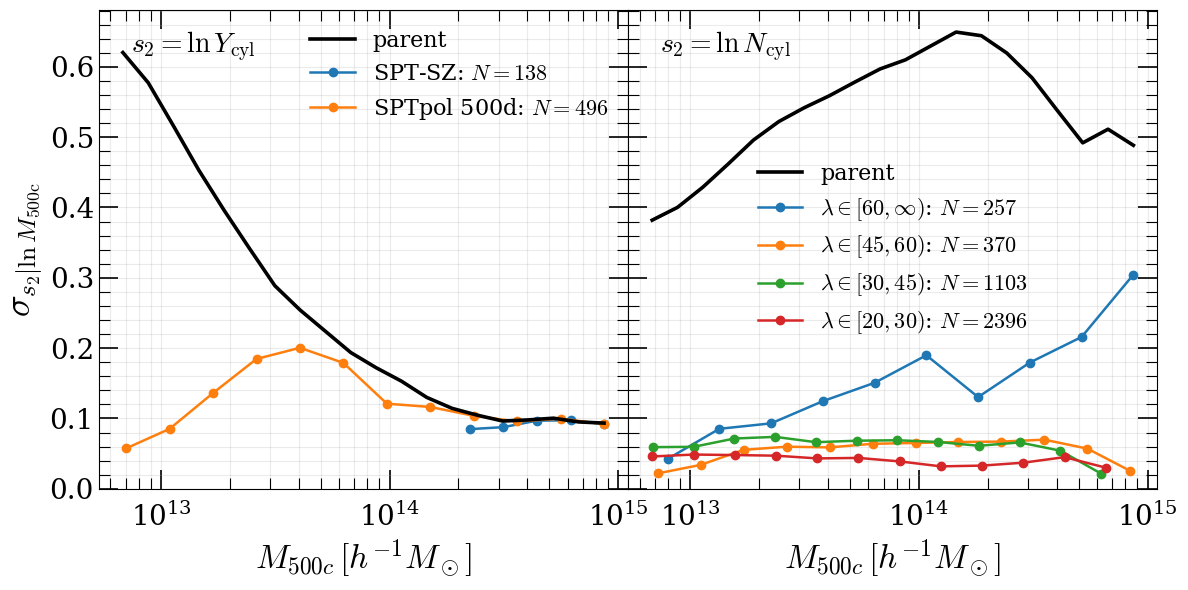

In [6]:
# ---------------------------------------------------------------------
# Proxy scatter comparison: parent scatter and selected-sample refits
# ---------------------------------------------------------------------

def fit_selected_proxy_scatter_curve(mass, proxy, *, kernel_width=KLLR_KERNEL_WIDTH,
                                     bins_max=SELECTED_KLLR_BINS_MAX,
                                     min_points=SELECTED_KLLR_MIN_POINTS):
    mass, proxy = finite_positive_pair(mass, proxy)
    n = len(mass)
    if n < min_points:
        print(f"[skip] only {n} valid objects; need at least {min_points}")
        return np.array([]), np.array([]), n
    x = np.log(mass)
    y = np.log(proxy)
    bins_use = int(min(bins_max, max(5, n // 25)))
    lm = kllr_model(kernel_type="gaussian", kernel_width=kernel_width)
    xg, y_exp, intercept, slope, scatter, _, _ = lm.fit(
        x, y, bins=bins_use, xrange=[float(np.nanmin(x)), float(np.nanmax(x))]
    )
    xg = np.asarray(xg, dtype=float)
    scatter = collapse_kllr_curve(scatter, xg, name="selected scatter")
    good = np.isfinite(xg) & np.isfinite(scatter)
    return np.exp(xg[good]), scatter[good], n


def plot_parent_and_selected_proxy_scatter(savepath=None):
    fig, axes = plt.subplots(1, 2, figsize=(12, 6.0), sharex=True, sharey=True)
    ax_y, ax_n = axes

    M_parent_y, sig_parent_y = load_parent_proxy_scatter(YCYL_FILE, source="ycyl", selector=YCYL_SELECTOR, obs=MODEL_OBS)
    ax_y.plot(M_parent_y, sig_parent_y, color="k", lw=2.6, label="parent", zorder=5)
    colors_y = {"SPT-SZ": "C0", "SPTpol 500d": "C1"}
    for name, d in ycyl_selected_samples.items():
        M_sel, sig_sel, n_used = fit_selected_proxy_scatter_curve(d["mass"], d["proxy"])
        if len(M_sel) > 0:
            ax_y.plot(M_sel, sig_sel, marker="o", ms=6, lw=1.8,
                      color=colors_y.get(name, None), label=fr"{name}: $N={n_used}$")
    ax_y.text(0.06,0.96,
        r"$s_2 = \ln Y_{\rm cyl}$", fontsize=20,
        transform=ax_y.transAxes, ha='left', va='top'
             )
    ax_y.set_ylabel(r"$\sigma_{s_2 | \ln M_{\rm 500c}}$", fontsize=26)

    M_parent_n, sig_parent_n = load_parent_proxy_scatter(RICH_FILE, source="richness", selector=None, obs=MODEL_OBS)
    ax_n.plot(M_parent_n, sig_parent_n, color="k", lw=2.6, label="parent", zorder=5)
    colors_n = {RICHNESS_BIN_LABELS[i]: f"C{i}" for i in range(4)}
    for name, d in ncyl_selected_samples.items():
        M_sel, sig_sel, n_used = fit_selected_proxy_scatter_curve(d["mass"], d["proxy"])
        if len(M_sel) > 0:
            ax_n.plot(M_sel, sig_sel, marker="o", ms=6, lw=1.8,
                      color=colors_n.get(name, None), label=fr"{name}: $N={n_used}$")
    # ax_n.set_title(r"$s_2 = \ln N_{\rm cyl}$", fontsize=20)
    ax_n.text(0.06,0.96,
        r"$s_2 = \ln N_{\rm cyl}$", fontsize=20,
        transform=ax_n.transAxes, ha='left', va='top'
             )
    
    # ax_n.set_ylabel(r"$\sigma_{\ln S|M}$", fontsize=16)

    for ax in axes:
        ax.set_xscale("log")
        ax.set_xlabel(r"$M_{500c}\,[h^{-1}M_\odot]$", fontsize=24)
        ax.grid(True, which="both", alpha=0.25)
        ax.legend(frameon=False, fontsize=16, loc='best') #[0.4,0.6]) #
        ax.tick_params(axis="both", which="both", labelsize=20, top=True, right=True, direction="in")
        ax.minorticks_on()
        ax.set_ylim(bottom=0.0)
    fig.tight_layout()
    fig.subplots_adjust(wspace=0.0, hspace=0.0)

    if savepath is not None:
        savepath = Path(savepath)
        fig.savefig(savepath, dpi=180, bbox_inches="tight")
        fig.savefig(savepath.with_suffix(".pdf"), bbox_inches="tight")
        print("Saved:", savepath)
        print("Saved:", savepath.with_suffix(".pdf"))
    return fig, axes

fig, axes = plot_parent_and_selected_proxy_scatter(
    savepath=None, #"proxy_scatter_parent_vs_selected_Ycyl_Ncyl.pdf"
)
plt.show()

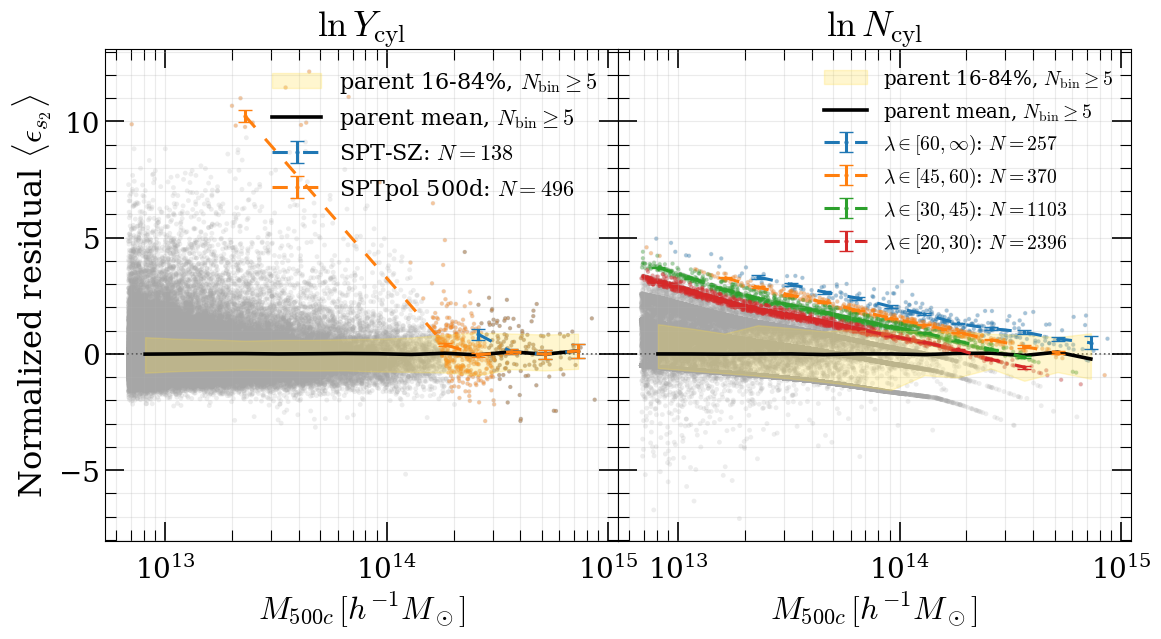

In [7]:
fig, axes = plot_proxy_residuals_vs_mass_two_cols(
    ycyl_parent_res=ycyl_parent_res,
    ycyl_selected_residuals=ycyl_selected_residuals,
    ncyl_parent_res=ncyl_parent_res,
    ncyl_selected_residuals=ncyl_selected_residuals,
    value_key="eps",
    n_mass_bins=14,
    min_count_parent_mean=5,
    min_count_parent_band=5,
    min_count_selected=5,
    savepath=None, #"normalized_residual_vs_mass_parent_vs_selected_with_points.png",
    show_individual_points=True,
    parent_point_alpha=0.20,
    selected_point_alpha=0.35,
    parent_point_size=12,
    selected_point_size=8,
)
plt.show()

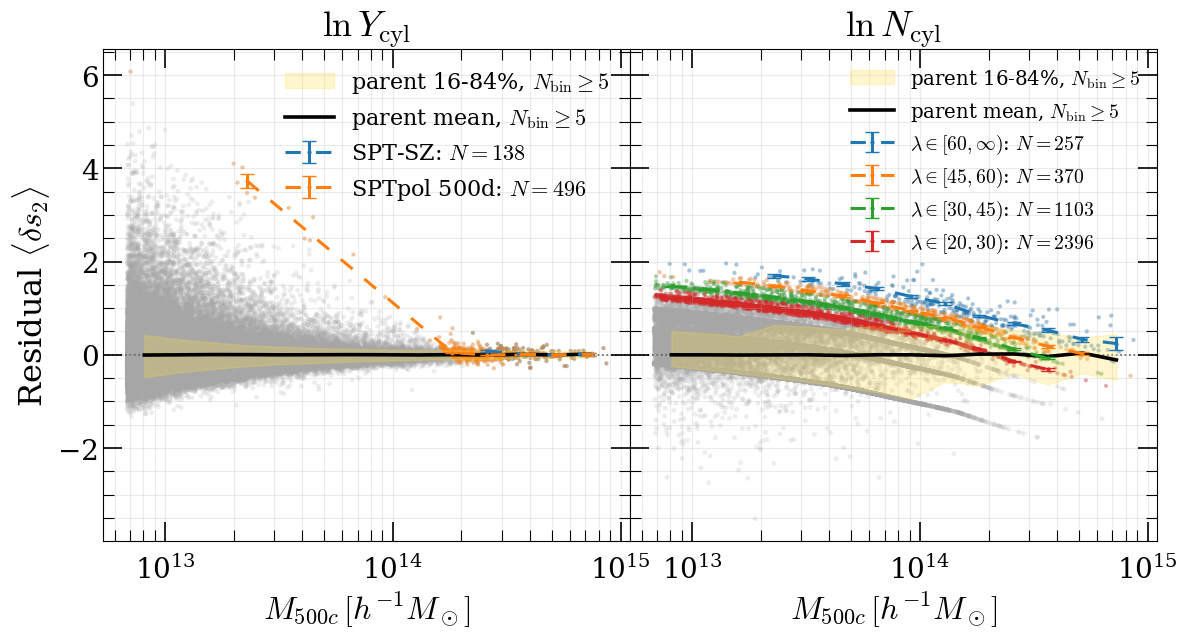

In [8]:
fig, axes = plot_proxy_residuals_vs_mass_two_cols(
    ycyl_parent_res=ycyl_parent_res,
    ycyl_selected_residuals=ycyl_selected_residuals,
    ncyl_parent_res=ncyl_parent_res,
    ncyl_selected_residuals=ncyl_selected_residuals,
    value_key="delta",
    n_mass_bins=14,
    min_count_parent_mean=5,
    min_count_parent_band=5,
    min_count_selected=5,
    savepath=None, # "proxy_raw_log_residual_vs_mass_parent_vs_selected_with_points.png",
    show_individual_points=True,
    parent_point_alpha=0.20,
    selected_point_alpha=0.35,
    parent_point_size=12,
    selected_point_size=8,
)
plt.show()